In [93]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
import gget
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
import itertools
from scipy import sparse
from scipy.sparse import csr_matrix

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from collections import defaultdict
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import euclidean
import matplotlib.lines as mlines

sc.settings.verbosity = 1

# Load in HWG data

In [2]:
path1 = "../../resources/HWG/MYOD Influencers.csv"
path2 = "../../resources/HWG/MYOD Target.csv"
path3 = "../../resources/HWG/PRRX1 Influencers.csv"
path4 = "../../resources/HWG/PRRX1 Target.csv"

def load_and_rename(path, gene, role):
    df = pd.read_csv(path)
    df = df.rename(columns={
        f"{gene} {role}": "gene",
        f"{gene} {role} ID": "gene_id",
        f"{gene} {role} degree centrality": "degree_centrality",
        f"{gene} {role} Eigenvector centrality": "eigenvector_centrality"
    })
    return df

myod_inf = load_and_rename(path1, "MYOD", "Influencer")
myod_tar = load_and_rename(path2, "MYOD", "Target")
prrx_inf = load_and_rename(path3, "PRRX1", "Influencer")
prrx_tar = load_and_rename(path4, "PRRX1", "Target")

for name, df in zip(
    ["MYOD Influencers", "MYOD Targets", "PRRX1 Influencers", "PRRX1 Targets"],
    [myod_inf, myod_tar, prrx_inf, prrx_tar]
):
    print(f"{name}: {df['gene'].nunique()} unique genes ({df.shape[0]} rows)")

MYOD Influencers: 170 unique genes (170 rows)
MYOD Targets: 544 unique genes (544 rows)
PRRX1 Influencers: 78 unique genes (78 rows)
PRRX1 Targets: 195 unique genes (195 rows)


In [3]:
myod_inf.head()

,gene,gene_id,degree_centrality,eigenvector_centrality
0,TP53,ENSG00000141510,0.171,0.079
1,MYC,ENSG00000136997,0.140,0.073
2,STAT3,ENSG00000168610,0.093,0.051
3,JUN,ENSG00000177606,0.090,0.051
4,NFKB1,ENSG00000109320,0.080,0.049


In [4]:
tfpath = "../../resources/allTFs_hg38.txt"

with open(tfpath, 'r') as file:
    tf_list = [line.strip() for line in file]

print(len(tf_list))

1892


In [42]:
path = "../../resources/HouseKeeping-GeneCards.csv"

hkdf = pd.read_csv(path)
hkdf = hkdf.rename(columns={'Gene Symbol': 'gene'})
print(hkdf.shape)

hk_genes = hkdf['gene'].unique()

hkdf.head()

(634, 8)


,gene,Description,Category,Uniprot ID,Gifts,GC Id,Relevance score,GeneCards Link
0,GAPDH,Glyceraldehyde-3-Phosphate Dehydrogenase,Protein Coding,P04406,64,GC12P080272,6.024998,https://www.genecards.org/cgi-bin/carddisp.pl?...
1,B2M,Beta-2-Microglobulin,Protein Coding,P61769,62,GC15P044711,3.963092,https://www.genecards.org/cgi-bin/carddisp.pl?...
2,HPRT1,Hypoxanthine Phosphoribosyltransferase 1,Protein Coding,P00492,60,GC0XP134460,3.547013,https://www.genecards.org/cgi-bin/carddisp.pl?...
3,SURF4,Surfeit 4,Protein Coding,O15260,50,GC09M133361,2.606426,https://www.genecards.org/cgi-bin/carddisp.pl?...
4,TBP,TATA-Box Binding Protein,Protein Coding,P20226,62,GC06P170554,2.571569,https://www.genecards.org/cgi-bin/carddisp.pl?...


# Load in processed data

In [3]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.38 GB, difference +2.38 GB
CPU times: user 540 ms, sys: 2.35 s, total: 2.89 s
Wall time: 4.33 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [6]:
adata.var.head()

,gene_id,gene_type,Chromosome,Start,End,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,...,total_counts,log1p_total_counts,n_counts,filter_pass,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
gene_name,,,,,,,,,,,,,,,,,,,,,
A1BG,ENSG00000121410,protein_coding,chr19,58345177,58353492,False,False,8565,0.743217,0.555732,...,14353.0,9.571784,13983.0,True,False,NaN,0.395181,0.190637,1.027514,0
A1BG-AS1,ENSG00000268895,lncRNA,chr19,58347717,58355455,False,False,1339,0.074461,0.071820,...,1438.0,7.271704,1379.0,False,False,NaN,0.047152,0.028002,0.964666,0
A1CF,ENSG00000148584,protein_coding,chr10,50799408,50885675,False,False,74,0.004091,0.004082,...,79.0,4.382027,77.0,True,False,NaN,0.002697,0.001801,0.962377,0
A2M,ENSG00000175899,protein_coding,chr12,9067663,9116229,False,False,1100,0.082850,0.079596,...,1600.0,7.378384,1568.0,True,True,365.0,0.046370,0.035322,1.174857,1
A2M-AS1,ENSG00000245105,lncRNA,chr12,9065162,9068689,False,False,64,0.003314,0.003309,...,64.0,4.174387,64.0,False,False,NaN,0.002294,0.001406,0.955376,0


In [5]:
adata.obs.head()

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,S_score,G2M_score,phase,leiden,cluster_str,leiden_split
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,7.992269,15.716183,False,False,-0.635702,4.894103,G2M,0,C1,H1
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,7.290293,15.135860,False,False,0.306563,-0.046410,S,1,C2,M1
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.283494,13.937025,False,False,-1.015544,-1.571282,G1,0,C1,H1
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,7.260523,14.684015,False,False,0.139403,3.017692,G2M,2,C3,P2
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.080856,17.547386,False,False,-0.391932,4.534103,G2M,2,C3,P2


# DGE

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [6]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [7]:
# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="leiden_split",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='cluster_deg',
)

In [8]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

sig = get_significant_DEGs(deg)#, pct_nz_thresh=0.2)

sig['is_tf'] = sig['names'].isin(tf_list)

# filter for upregulated genes that are expressed in a certain proportion of cells
pct_thresh = 0.2

sig = sig[
    (sig['logfoldchanges'] < 0) | # retain all downregulated genes
    ((sig['logfoldchanges'] > 0) & (sig['pct_nz_group'] >= pct_thresh))
]

print(f'N genes: {sig['names'].nunique()}')

sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9882

N genes: 6264


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,is_tf
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,True
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089,False
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,False


In [9]:
mdf = sig[sig['names'].isin(myod_tar['gene'].unique())]
print(f'N genes: {mdf['names'].nunique()}')

N genes: 190


In [10]:
def plot_de_gene_subset(df, condition, gene_list, n_genes, title_gene):

    tmp = df[df['group'] == condition]
    tmp = tmp[tmp['names'].isin(gene_list)]
    
    # select top DE genes
    tmp = tmp.sort_values(by='abs_lfc', ascending=False).head(n_genes)
    
    # sort by logfc for plotting
    tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 8, 2

    colors = ["silver", "tab:cyan"]

    sns.barplot(
        data=tmp,
        x='names',
        y='logfoldchanges',
        hue='is_tf',
        palette=colors,
        width=0.5,
        ec='k', 
        zorder=1,
        legend=False,
    )

    plt.axhline(y=0, color='k', linestyle='--', lw=0.75, zorder=0)

    plt.ylabel("log$_2$ Fold Change")
    plt.xlabel("")

    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8, rotation=90)

    plt.title(f"Top {n_genes} DE {title_gene} Targets | {condition} vs Control", fontsize=10)

    sns.despine()
    plt.show()

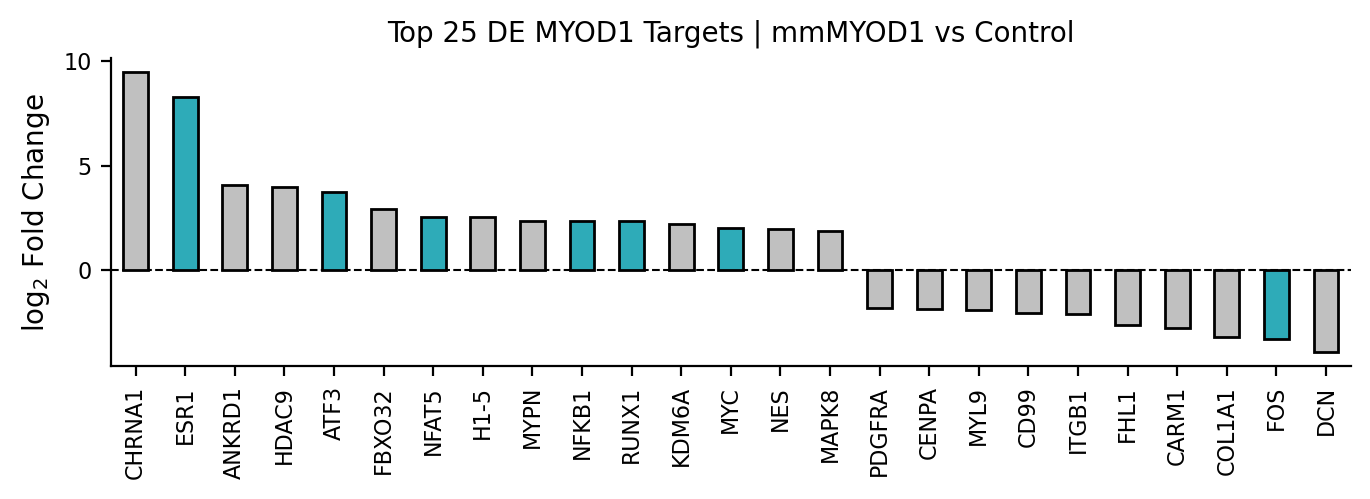

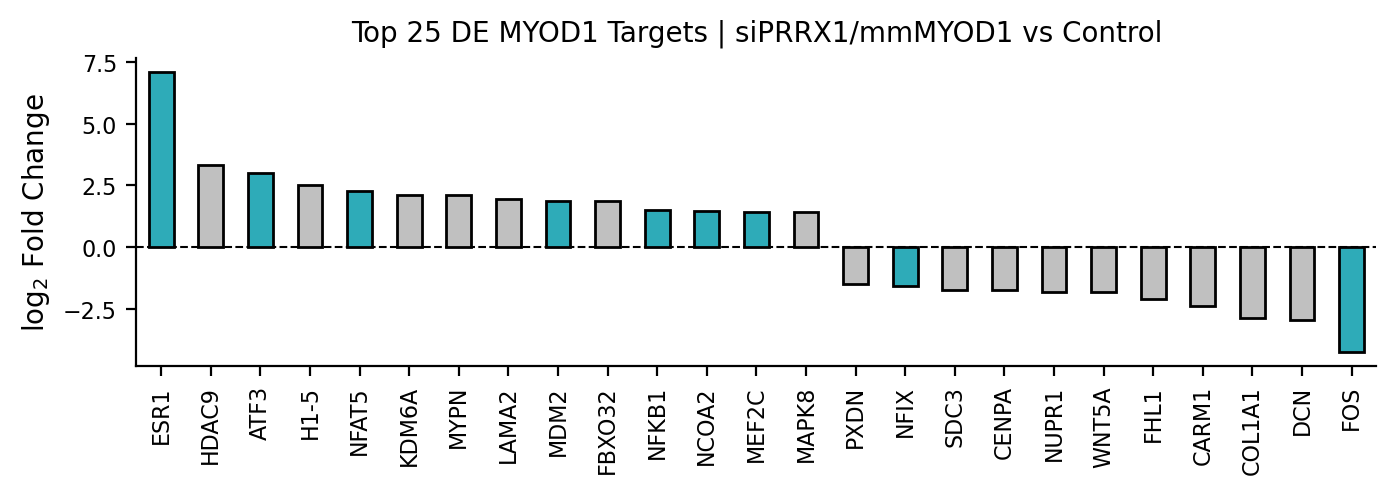

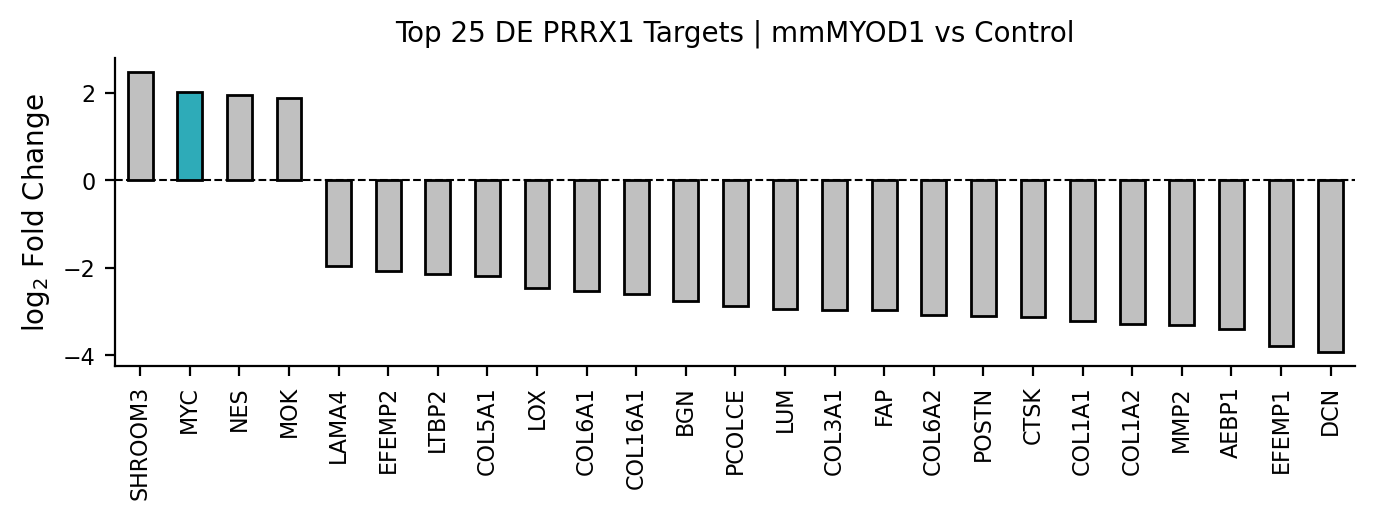

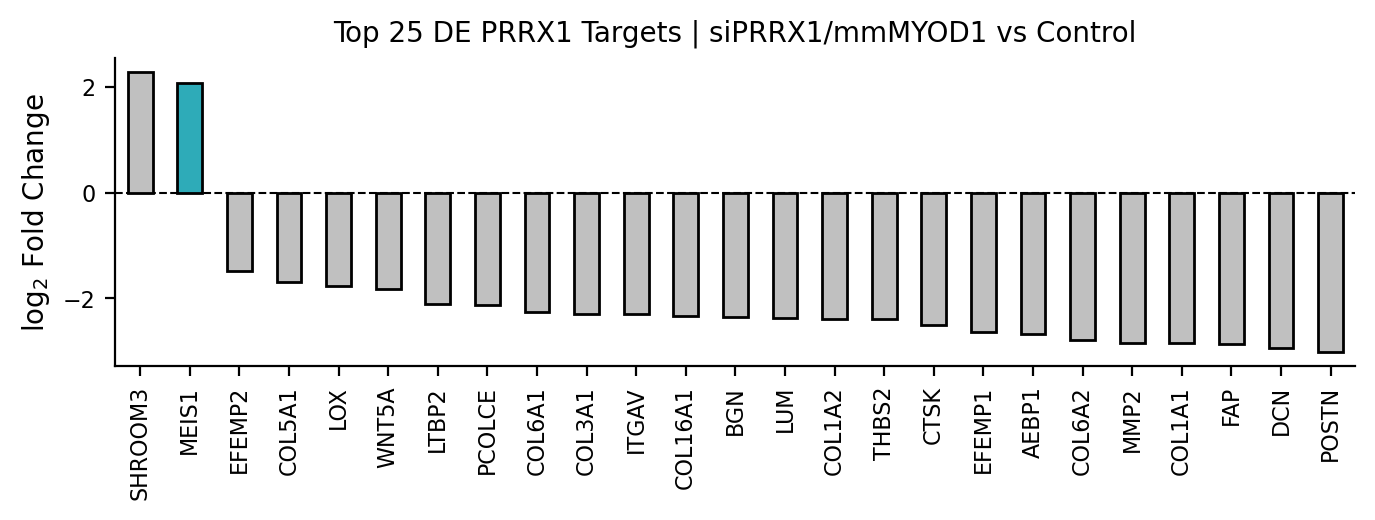

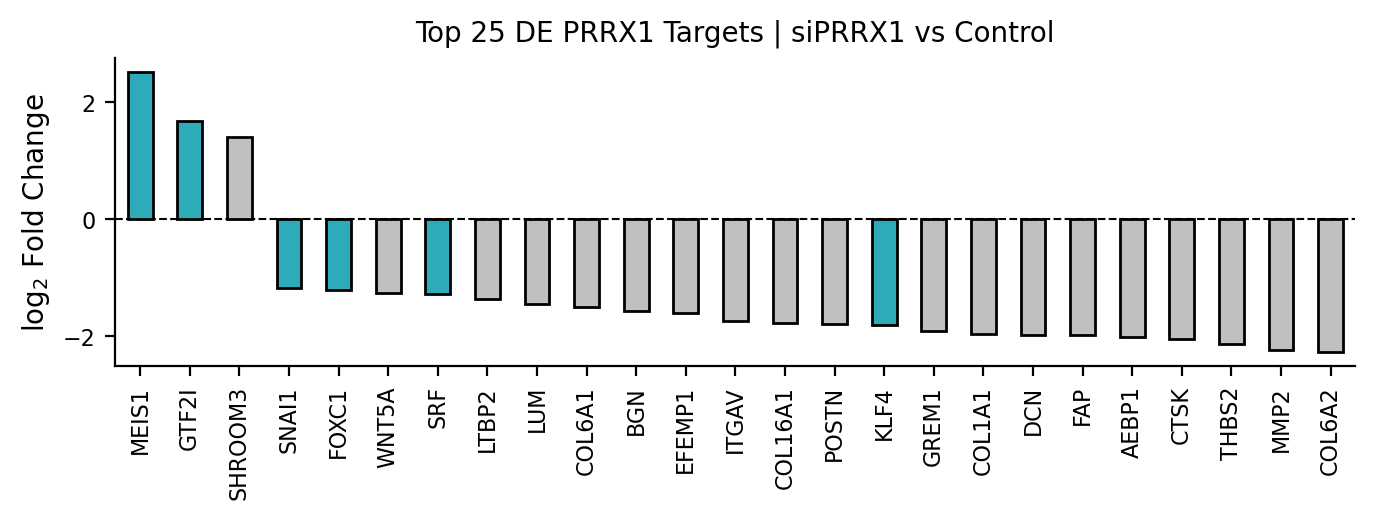

In [11]:
plot_de_gene_subset(sig, 'mmMYOD1', gene_list=myod_tar['gene'].unique(), n_genes=25, title_gene='MYOD1')
plot_de_gene_subset(sig, 'siPRRX1/mmMYOD1', gene_list=myod_tar['gene'].unique(), n_genes=25, title_gene='MYOD1')

plot_de_gene_subset(sig, 'mmMYOD1', gene_list=prrx_tar['gene'].unique(), n_genes=25, title_gene='PRRX1')
plot_de_gene_subset(sig, 'siPRRX1/mmMYOD1', gene_list=prrx_tar['gene'].unique(), n_genes=25, title_gene='PRRX1')
plot_de_gene_subset(sig, 'siPRRX1', gene_list=prrx_tar['gene'].unique(), n_genes=25, title_gene='PRRX1')

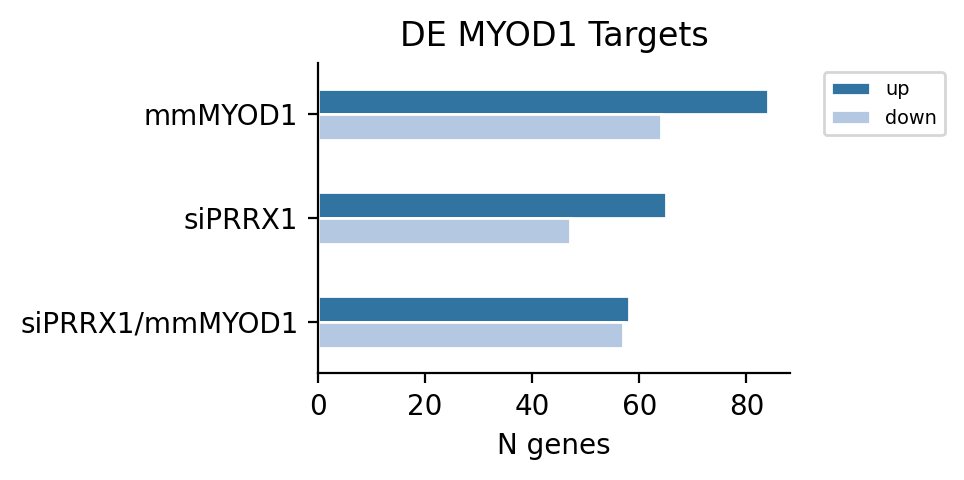

In [12]:
tmp = sig[sig['names'].isin(myod_tar['gene'].unique())].copy()

tmp['direction'] = np.where(tmp['logfoldchanges'] > 0, 'up', 'down')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.countplot(
    data=tmp,
    y='group',
    hue='direction',
    palette='tab20',
    width=0.5,
    ec='white',
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize='x-small',
)

plt.ylabel("")
plt.xlabel("N genes")
plt.title("DE MYOD1 Targets")

sns.despine()
plt.tight_layout()
plt.show()

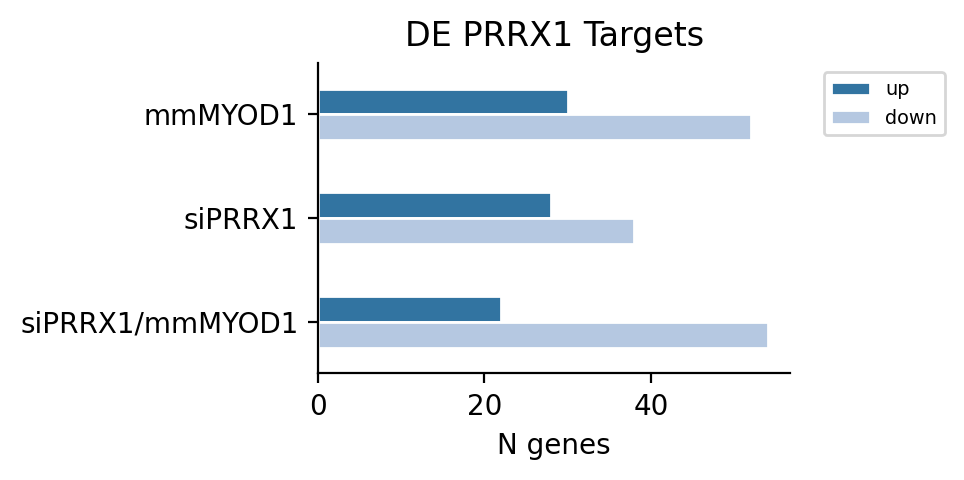

In [13]:
tmp = sig[sig['names'].isin(prrx_tar['gene'].unique())].copy()

tmp['direction'] = np.where(tmp['logfoldchanges'] > 0, 'up', 'down')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.countplot(
    data=tmp,
    y='group',
    hue='direction',
    palette='tab20',
    width=0.5,
    ec='white',
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize='x-small',
)

plt.ylabel("")
plt.xlabel("N genes")
plt.title("DE PRRX1 Targets")

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
sig_genes = set(sig['names'])

myod1_targets_filtered = myod_tar[myod_tar['gene'].isin(sig_genes)]
prrx1_targets_filtered = prrx_tar[prrx_tar['gene'].isin(sig_genes)]

top24_myod1 = myod1_targets_filtered.nlargest(24, 'eigenvector_centrality')
top24_prrx1 = prrx1_targets_filtered.nlargest(24, 'eigenvector_centrality')

gene_list = ['MYOD1'] + top24_myod1['gene'].tolist() + ['PRRX1'] + top24_prrx1['gene'].tolist()
gene_list = list(dict.fromkeys(gene_list))
print(len(gene_list))

genes_to_plot = sig[sig['names'].isin(gene_list)].copy()

47


In [16]:
from matplotlib import cm
from matplotlib.colors import Normalize

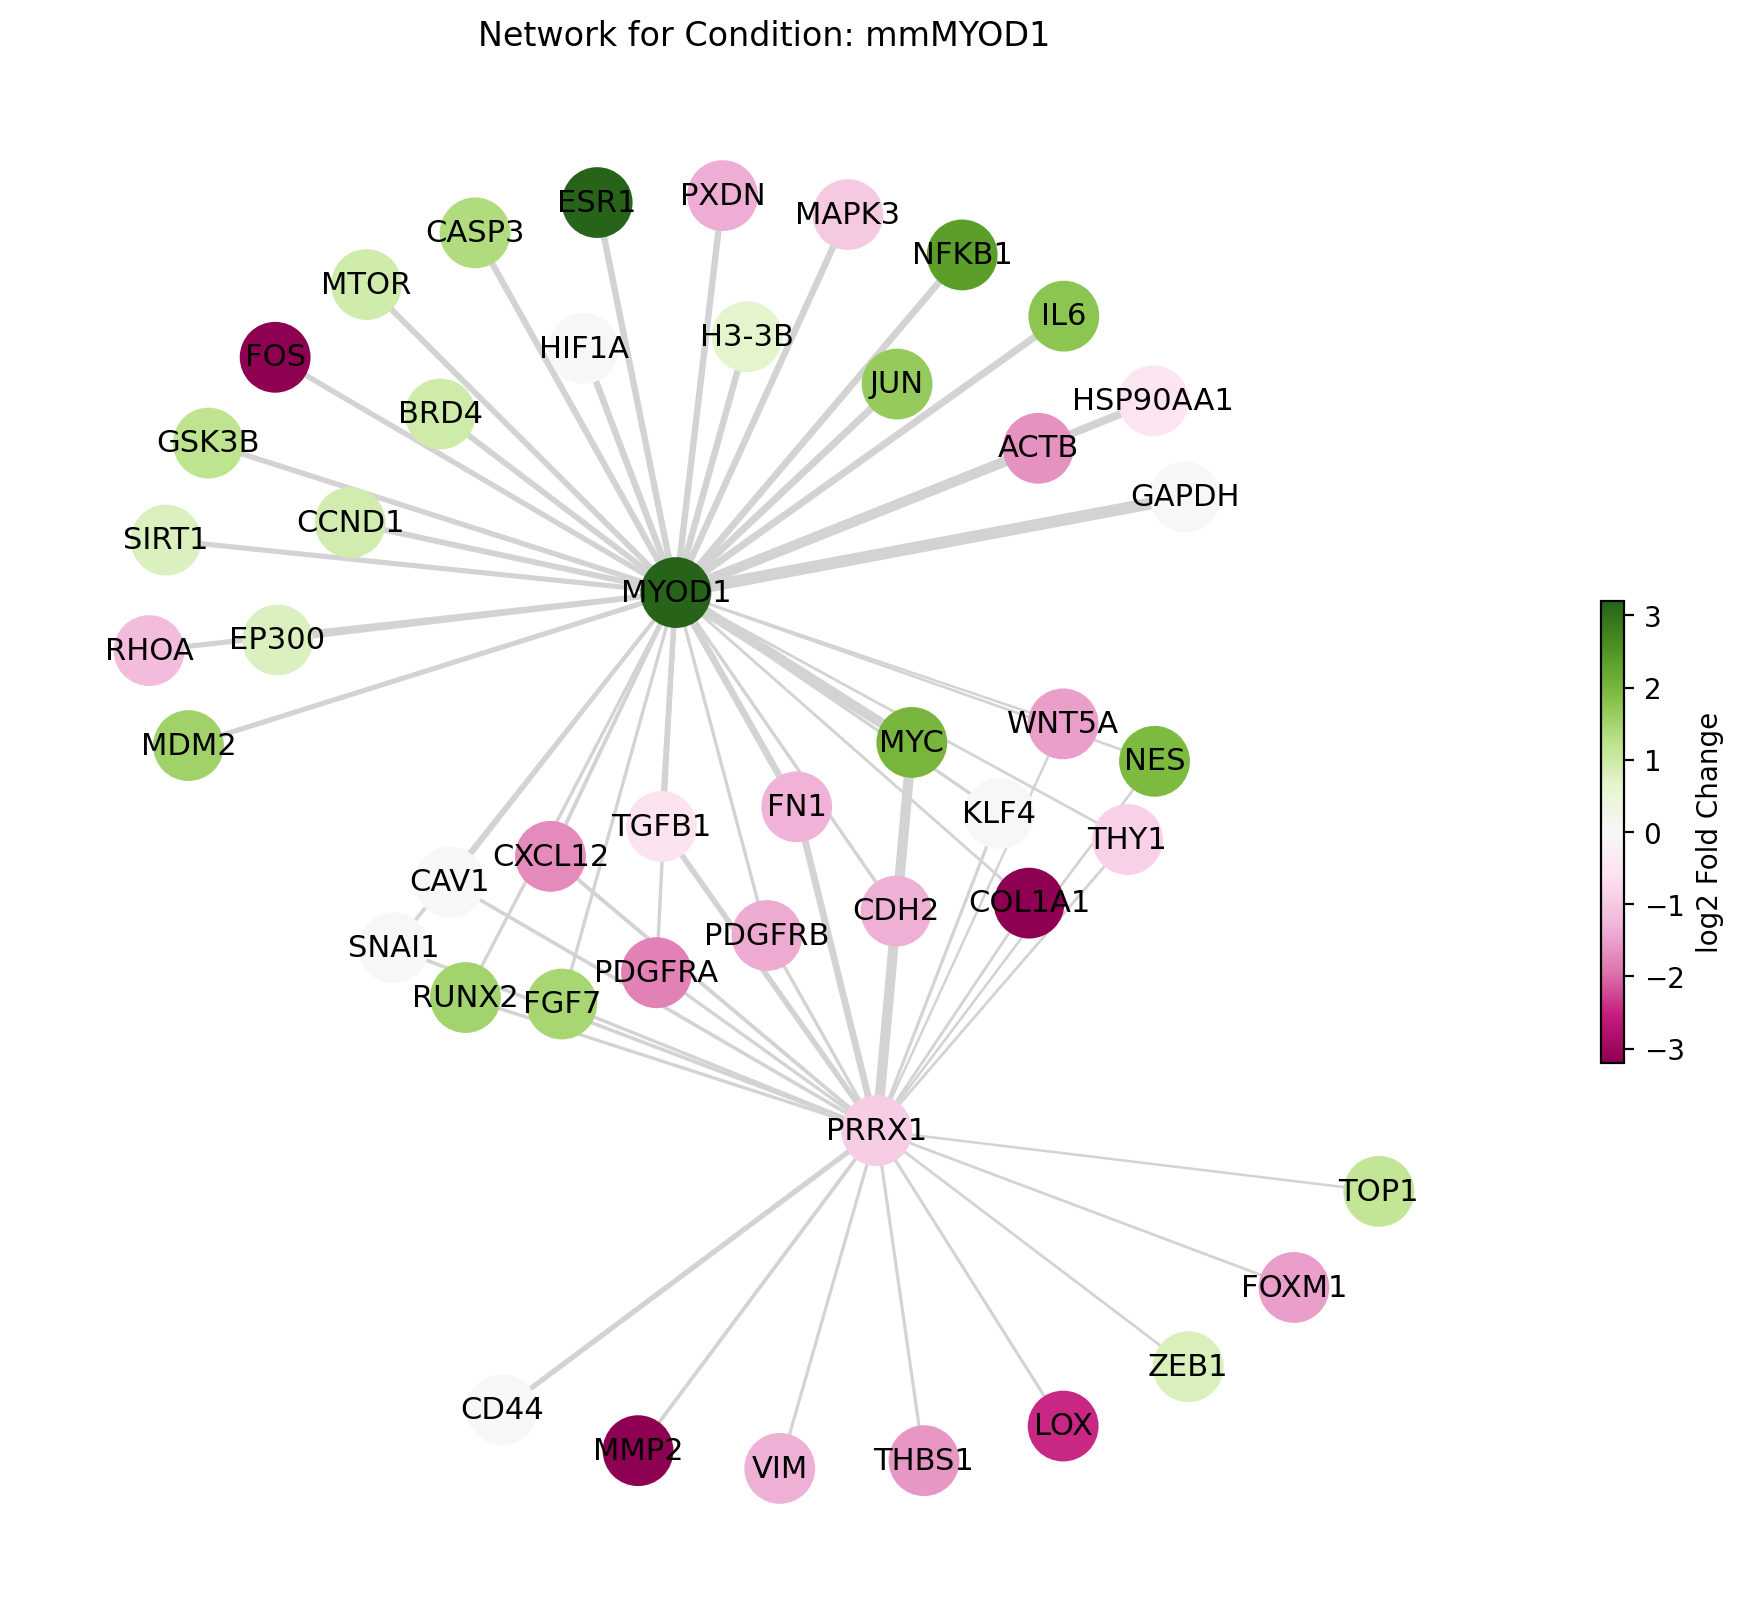

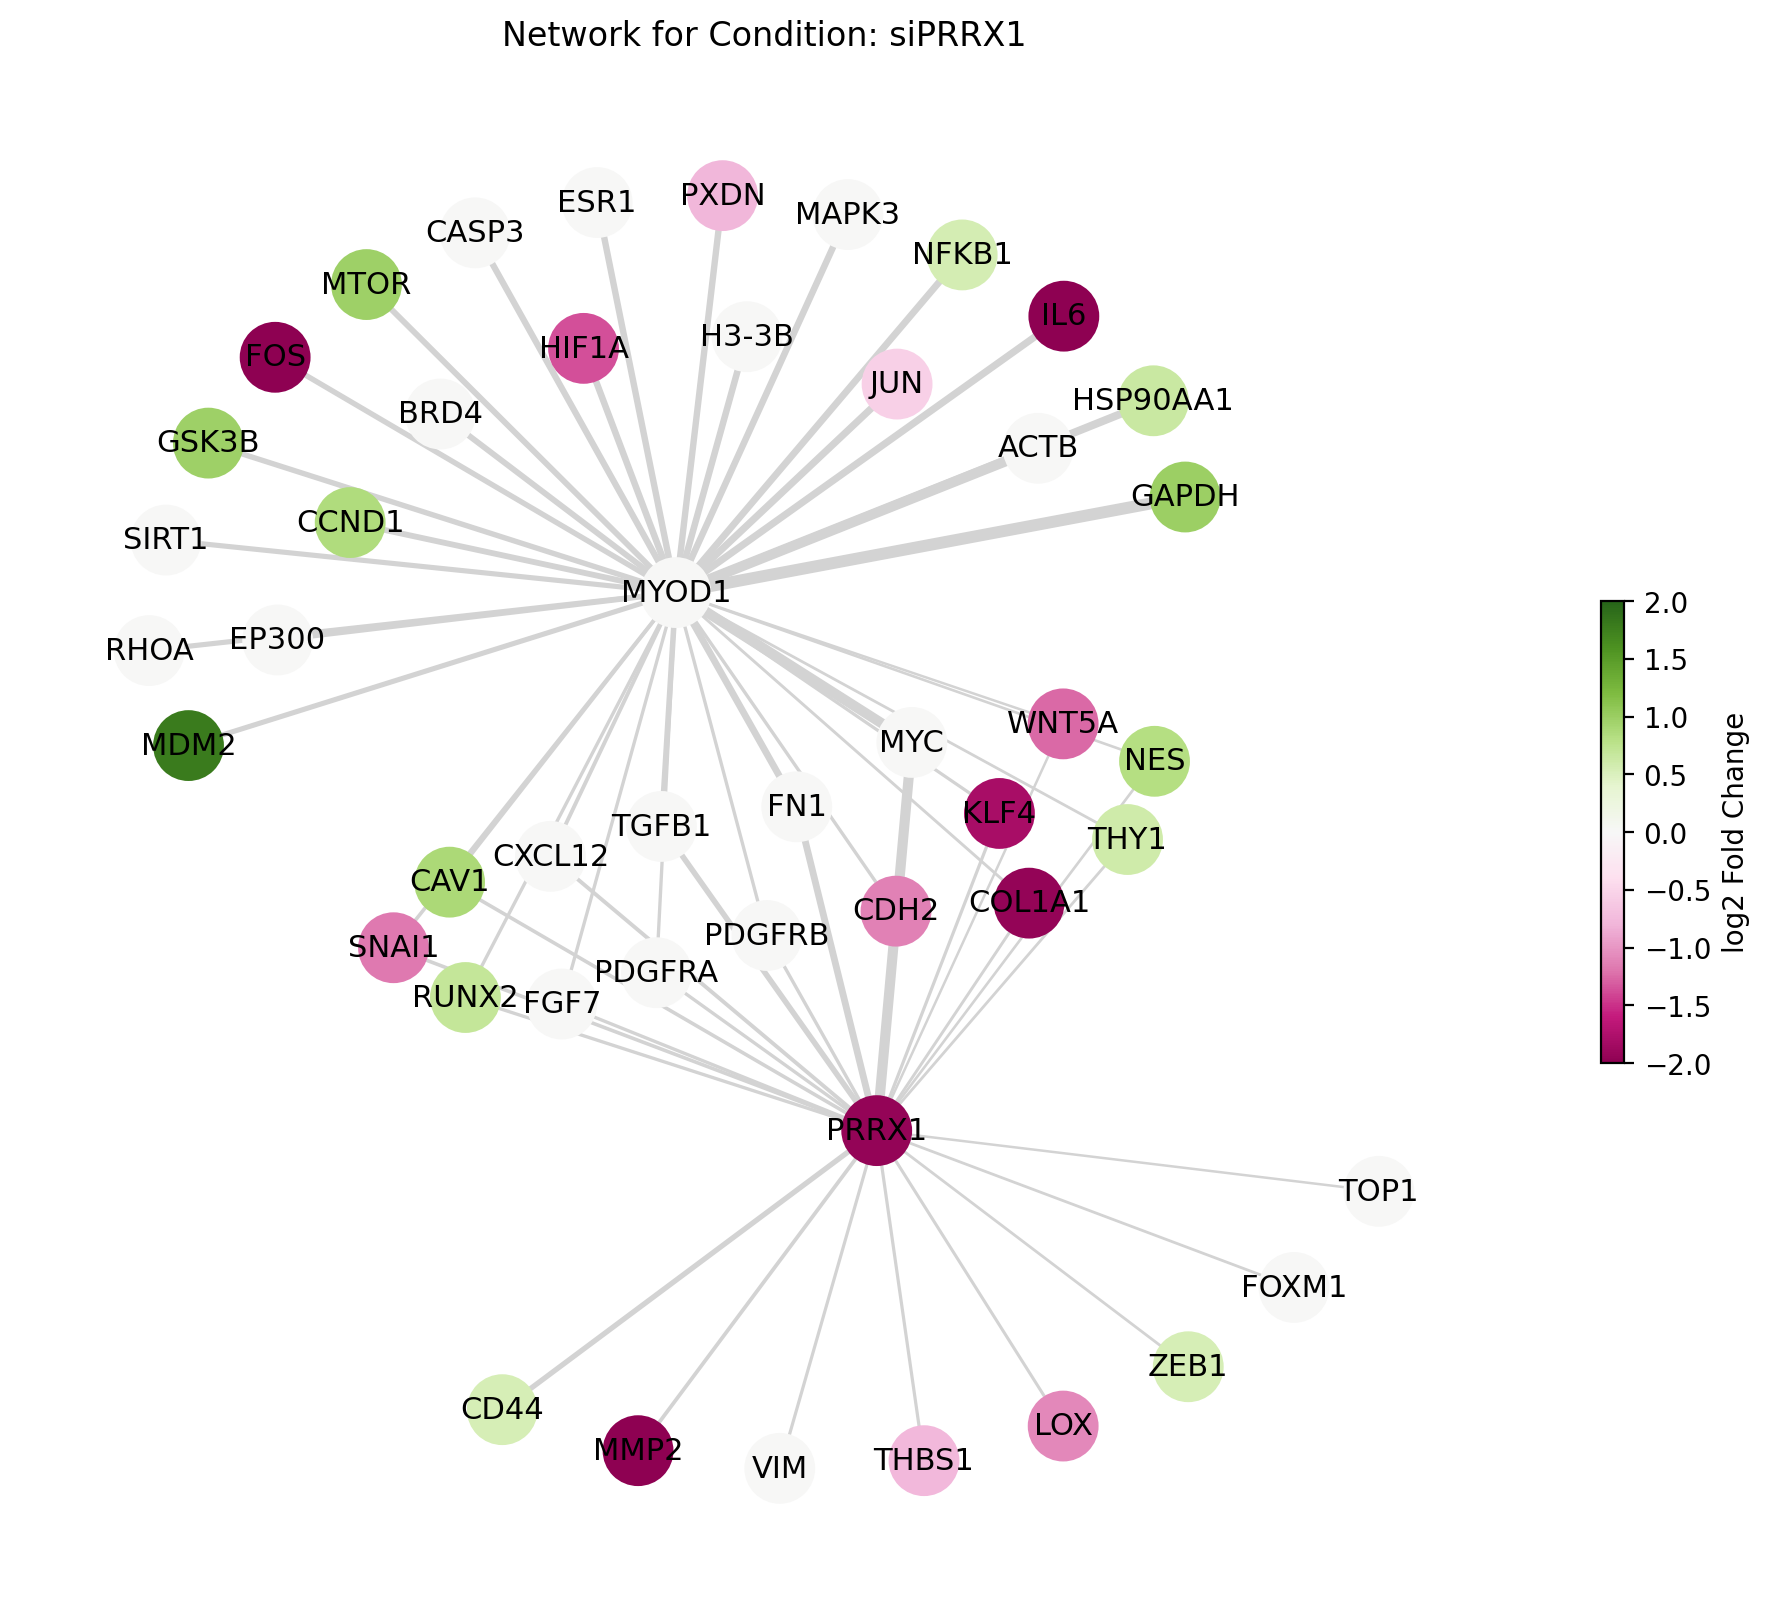

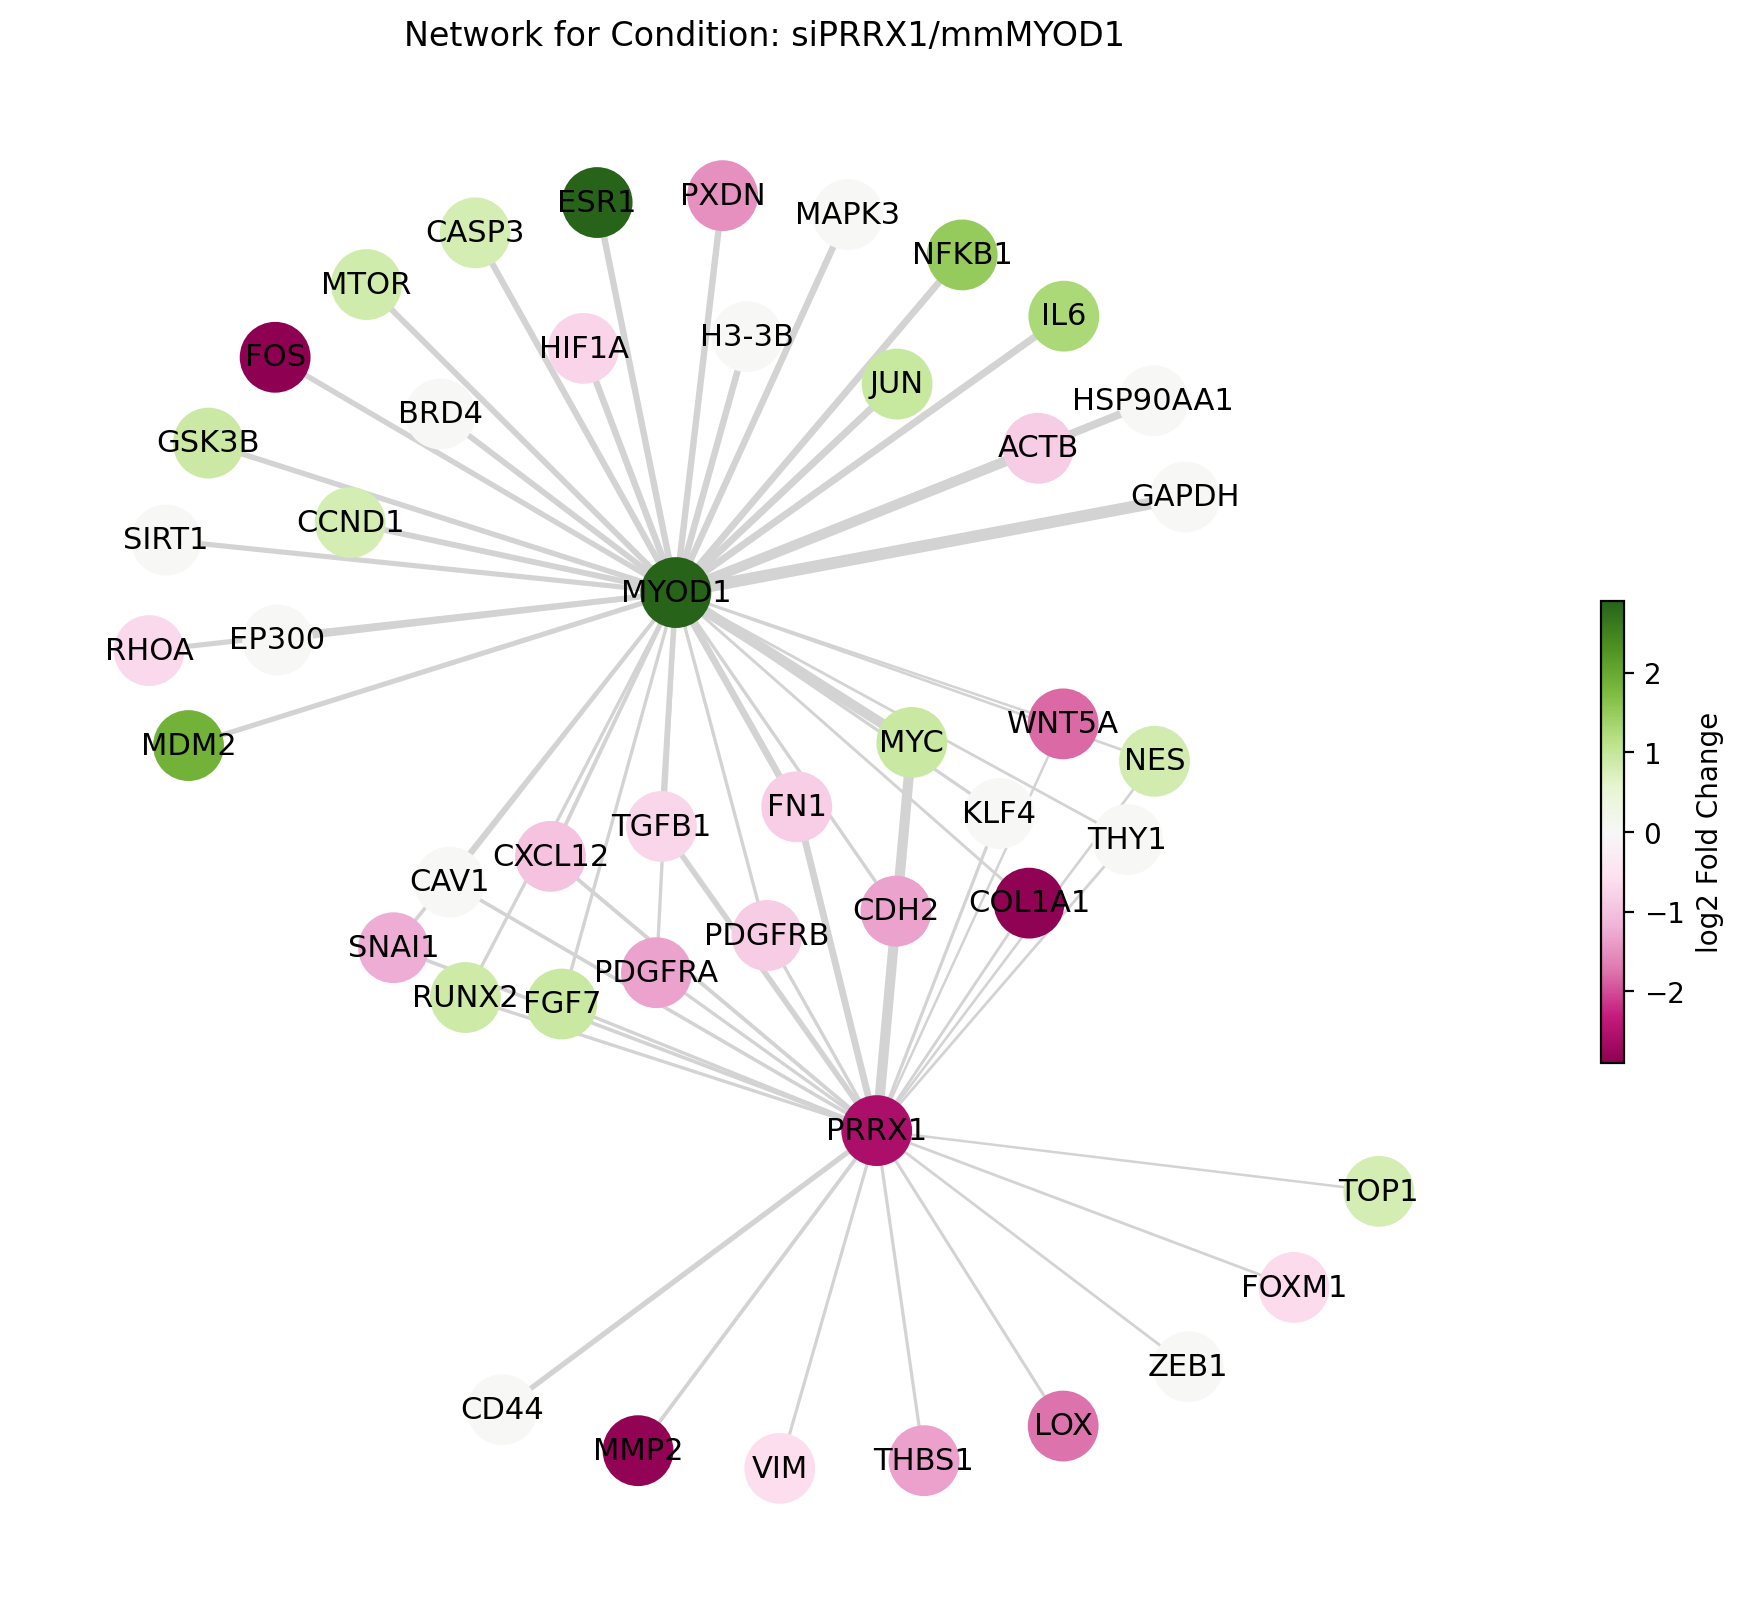

In [28]:
myod1_centrality = dict(zip(myod_tar['gene'], myod_tar['eigenvector_centrality']))
prrx1_centrality = dict(zip(prrx_tar['gene'], prrx_tar['eigenvector_centrality']))


for group, group_data in sig[sig['names'].isin(gene_list)].groupby('group'):
    G = nx.Graph()
    
    # Add central nodes
    G.add_node('MYOD1')
    G.add_node('PRRX1')
    
    for gene in gene_list:
        if gene in ('MYOD1', 'PRRX1'):
            continue
        G.add_node(gene)
        # Add edge to MYOD1 if it's a MYOD1 target
        if gene in myod1_centrality:
            G.add_edge('MYOD1', gene, weight=myod1_centrality[gene])
        # Add edge to PRRX1 if it's a PRRX1 target
        if gene in prrx1_centrality:
            G.add_edge('PRRX1', gene, weight=prrx1_centrality[gene])
    
    node_fc = group_data.set_index('names')['logfoldchanges'].to_dict()
    all_nodes = list(G.nodes())
    fc_values = [node_fc.get(node, 0.0) for node in all_nodes]
    
    # lim = max(abs(min(fc_values)), abs(max(fc_values)))
    quant = group_data['abs_lfc'].quantile(0.9)
    vmin, vmax = -quant.round(1), quant.round(1)
    # vmin, vmax = -7, 7
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps['PiYG']
    node_colors = [cmap(norm(fc)) for fc in fc_values]

    
    # Set size and color for plotting
    sizes = [600] * len(all_nodes)
    
    # Draw
    fig, ax = plt.subplots(figsize=(12,10))
    
    # pos = nx.spring_layout(G, seed=42, k=0.5, iterations=100)
    pos = nx.kamada_kawai_layout(G, scale=2, weight=None)
    # shells = [['MYOD1', 'PRRX1'], list(set(G.nodes()) - {'MYOD1', 'PRRX1'})]
    # pos = nx.shell_layout(G, shells)
    
    edges = G.edges()
    weights = [G[u][v]['weight']*50 for u,v in edges]

    nx.draw(G, pos,
           with_labels=True,
           node_color=node_colors,
           node_size=sizes,
           width=weights,
           edge_color='lightgray',
           alpha=1,
           font_size=11,
           ax=ax
           )
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, label='log2 Fold Change', shrink=0.3)
    
    plt.title(f"Network for Condition: {group}")
    plt.axis('off')
    plt.show()
    
    # break

In [18]:
group_data.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,is_tf
0,mmMYOD1,MYOD1,69.678673,32.184513,0.000000e+00,0.000000e+00,1.000000,32.184513,True
48,mmMYOD1,ESR1,38.310966,8.280114,0.000000e+00,0.000000e+00,0.552394,8.280114,True
58,mmMYOD1,TOP1,36.958736,1.126108,5.272916e-299,5.367657e-297,0.944998,1.126108,False
136,mmMYOD1,NES,30.909449,1.948990,8.917195e-210,5.568688e-208,0.659080,1.948990,False
165,mmMYOD1,H3-3B,29.577080,0.652672,2.946315e-192,1.597005e-190,0.994310,0.652672,False


In [26]:
quant = group_data['abs_lfc'].quantile(0.9)

vmin, vmax = -quant.round(1), quant.round(1)

print(vmin)
print(vmax)

-3.2
3.2


# Distances

In [42]:
adata

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [44]:
bdata = adata[:, adata.var['gene_type'] == 'protein_coding']

bdata

View of AnnData object with n_obs × n_vars = 15950 × 15786
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_r

In [37]:
from scipy import sparse
import numpy as np, pandas as pd, networkx as nx
from scipy.sparse import csr_matrix
import scipy.sparse.linalg as spla

In [98]:
%%time
conditions = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

# extract protein-coding genes
bdata = adata[:, adata.var['gene_type'] == 'protein_coding'].copy()

corr_matrices = {}

corr_matrices_notabs = {}

centrality_results = {}
threshold = 0.2

for cond in conditions:
    print(f"\nProcessing condition: {cond}")
    
    # Subset condition
    tmp = bdata[bdata.obs['pooled_condition'] == cond].copy()
    
    # Filter to top most variable genes
    sc.pp.highly_variable_genes(tmp, n_top_genes=5000, flavor="seurat_v3", layer='raw_counts')
    tmp = tmp[:, tmp.var['highly_variable']].copy()
    gene_names = tmp.var_names
    print(f"Selected {len(gene_names)} highly variable genes")

    # Get log-normalized expression (dense)
    tmp.X = tmp.layers['log_norm']
    X = tmp.X.toarray() if isinstance(tmp.X, csr_matrix) else tmp.X

    # --- Fast correlation computation ---
    corr_matrix = np.corrcoef(X, rowvar=False)
    
    corr_matrices_notabs[cond] = pd.DataFrame(corr_matrix, index=gene_names, columns=gene_names)
    
    # take absolute value
    corr_abs = np.abs(corr_matrix)

    # Sparsify correlation matrix (remove weak correlations)
    corr_abs[corr_abs < threshold] = 0.001

    # Store for later if needed
    corr_matrices[cond] = pd.DataFrame(corr_abs, index=gene_names, columns=gene_names)

    # --- Centrality measures ---
    # Degree centrality (sum of edge weights)
    degree_centrality = corr_abs.sum(axis=1)
    degree_df = pd.Series(degree_centrality, index=gene_names, name='degree')

    # Eigenvector centrality using sparse matrix (power iteration)
    A = csr_matrix(corr_abs)
    try:
        vals, vecs = spla.eigs(A, k=1, which='LM')
        eigenvector_centrality = np.real(vecs[:, 0])
    except Exception as e:
        print(f"Eigenvector centrality failed for {cond}: {e}")
        eigenvector_centrality = np.zeros_like(degree_centrality)

    eigenvector_df = pd.Series(eigenvector_centrality, index=gene_names, name='eigenvector')

    # Combine centralities
    centrality_df = pd.concat([degree_df, eigenvector_df], axis=1)

    # Extract top 50 genes
    top_degree = centrality_df.sort_values('degree', ascending=False).head(50)
    top_eigenvector = centrality_df.sort_values('eigenvector', ascending=False).head(50)

    # Store
    centrality_results[cond] = {
        'full': centrality_df,
        'top_degree': top_degree,
        'top_eigenvector': top_eigenvector
    }

    # Display summary
    print(f"Top 10 degree centrality genes for {cond}:")
    display(top_degree.head(10))
    print(f"Top 10 eigenvector centrality genes for {cond}:")
    display(top_eigenvector.head(10))
    
    # break


Processing condition: Control
Selected 5000 highly variable genes
Top 10 degree centrality genes for Control:


,degree,eigenvector
gene_name,,
TOP2A,286.737941,0.092478
STMN1,284.928691,0.089871
PRC1,282.159121,0.090424
CENPF,282.120106,0.090985
HMGB2,280.116188,0.090522
TPX2,277.325743,0.089275
NUSAP1,276.594352,0.091034
MKI67,275.351637,0.087706
PTTG1,265.193273,0.088201


Top 10 eigenvector centrality genes for Control:


,degree,eigenvector
gene_name,,
TOP2A,286.737941,0.092478
NUSAP1,276.594352,0.091034
CENPF,282.120106,0.090985
HMGB2,280.116188,0.090522
PRC1,282.159121,0.090424
STMN1,284.928691,0.089871
TPX2,277.325743,0.089275
PTTG1,265.193273,0.088201
MKI67,275.351637,0.087706



Processing condition: mmMYOD1
Selected 5000 highly variable genes
Top 10 degree centrality genes for mmMYOD1:


...


Processing condition: siPRRX1/mmMYOD1
Selected 5000 highly variable genes
Top 10 degree centrality genes for siPRRX1/mmMYOD1:


,degree,eigenvector
gene_name,,
PTMA,388.855917,0.083481
GAPDH,382.695592,0.085588
PPP1R15A,362.774920,0.083276
ACTB,359.633035,0.082500
NME2,354.799637,0.082150
HSP90AA1,348.704488,0.078469
PPIA,346.685237,0.080020
TPM3,346.411339,0.080413
VIM,340.536758,0.079484


Top 10 eigenvector centrality genes for siPRRX1/mmMYOD1:


,degree,eigenvector
gene_name,,
GAPDH,382.695592,0.085588
PTMA,388.855917,0.083481
PPP1R15A,362.774920,0.083276
ACTB,359.633035,0.082500
NME2,354.799637,0.082150
TPM3,346.411339,0.080413
PPIA,346.685237,0.080020
VIM,340.536758,0.079484
CFL1,333.995851,0.079178


CPU times: user 20.4 s, sys: 8.95 s, total: 29.3 s
Wall time: 29.6 s


In [44]:
conditions = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']
top_n = 100

# --- DEGREE CENTRALITY ---
degree_cols = {}
degree_val_cols = {}

for cond in conditions:
    df = centrality_results[cond]['full'].copy()
    df = df.sort_values('degree', ascending=False).head(top_n)
    degree_cols[cond] = df.index.tolist()
    degree_val_cols[f"{cond}_degree"] = df['degree'].tolist()

degree_df = pd.DataFrame({**degree_cols, **degree_val_cols})
degree_df = degree_df.iloc[:top_n]
print(f"Degree centrality table: {degree_df.shape}")
display(degree_df.head())

Degree centrality table: (100, 8)


,Control,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1,Control_degree,mmMYOD1_degree,siPRRX1_degree,siPRRX1/mmMYOD1_degree
0,TOP2A,PTMA,MKI67,PTMA,286.737941,335.786124,194.985333,388.855917
1,STMN1,GAPDH,HMGB2,GAPDH,284.928691,328.040729,192.337608,382.695592
2,PRC1,PPP1R15A,H2AZ1,PPP1R15A,282.159121,325.881975,190.841204,362.774920
3,CENPF,ACTB,TOP2A,ACTB,282.120106,293.934837,184.591977,359.633035
4,HMGB2,S100A11,TMPO,NME2,280.116188,279.178422,182.572687,354.799637


In [45]:
# --- EIGENVECTOR CENTRALITY ---
eigen_cols = {}
eigen_val_cols = {}

for cond in conditions:
    df = centrality_results[cond]['full'].copy()
    df = df.sort_values('eigenvector', ascending=False).head(top_n)
    eigen_cols[cond] = df.index.tolist()
    eigen_val_cols[f"{cond}_eigenvector"] = df['eigenvector'].tolist()

eigen_df = pd.DataFrame({**eigen_cols, **eigen_val_cols})
eigen_df = eigen_df.iloc[:top_n]
print(f"Eigenvector centrality table: {eigen_df.shape}")
display(eigen_df.head())

Eigenvector centrality table: (100, 8)


,Control,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1,Control_eigenvector,mmMYOD1_eigenvector,siPRRX1_eigenvector,siPRRX1/mmMYOD1_eigenvector
0,TOP2A,GAPDH,ABTB3,GAPDH,0.092478,0.095838,-0.000264,0.085588
1,NUSAP1,PPP1R15A,PTGIR,PTMA,0.091034,0.092057,-0.000264,0.083481
2,CENPF,PTMA,SMAD3,PPP1R15A,0.090985,0.090918,-0.000264,0.083276
3,HMGB2,ACTB,PLAGL1,ACTB,0.090522,0.090788,-0.000264,0.082500
4,PRC1,SH3BGRL3,NT5DC3,NME2,0.090424,0.087812,-0.000264,0.082150


In [43]:
print(len(hk_genes))

634


In [46]:
degree_df[conditions] = degree_df[conditions].applymap(lambda g: np.nan if g in hk_genes else g) 
degree_df.head()

/tmp/ipykernel_3349450/3200880578.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  degree_df[conditions] = degree_df[conditions].applymap(lambda g: np.nan if g in hk_genes else g)


,Control,mmMYOD1,siPRRX1,siPRRX1/mmMYOD1,Control_degree,mmMYOD1_degree,siPRRX1_degree,siPRRX1/mmMYOD1_degree
0,TOP2A,PTMA,NaN,PTMA,286.737941,335.786124,194.985333,388.855917
1,STMN1,NaN,HMGB2,NaN,284.928691,328.040729,192.337608,382.695592
2,PRC1,PPP1R15A,H2AZ1,PPP1R15A,282.159121,325.881975,190.841204,362.774920
3,CENPF,NaN,TOP2A,NaN,282.120106,293.934837,184.591977,359.633035
4,HMGB2,S100A11,TMPO,NME2,280.116188,279.178422,182.572687,354.799637


In [48]:
control = degree_df['Control'].dropna().unique()
print(len(control))

myod = degree_df['mmMYOD1'].dropna().unique()
print(len(myod))

prrx = degree_df['siPRRX1'].dropna().unique()
print(len(prrx))

hyb = degree_df['siPRRX1/mmMYOD1'].dropna().unique()
print(len(hyb))

93
88
91
88


In [50]:
unique_to_myod = list(set(myod) - set(control) - set(prrx) - set(hyb))
print(len(unique_to_myod))
unique_to_myod

29


['SSR4',
 'S100A4',
 'RPS2',
 'CAP1',
 'VAMP5',
 'FXYD5',
 'PTN',
 'SEC61G',
 'MAGI2',
 'TPT1',
 'RRBP1',
 'AP2S1',
 'VXN',
 'ARPC2',
 'EEF1B2',
 'LAP3',
 'RPS9',
 'PSG9',
 'DPF3',
 'TLN1',
 'RUNX1',
 'GADD45B',
 'CACYBP',
 'DSTN',
 'PSG8',
 'SHROOM3',
 'ANKRD1',
 'PSMB9',
 'LRRC7']

In [72]:
from scipy.cluster.hierarchy import leaves_list
import matplotlib.patches as mpatches

t can range from 0.0000 to 1.1770


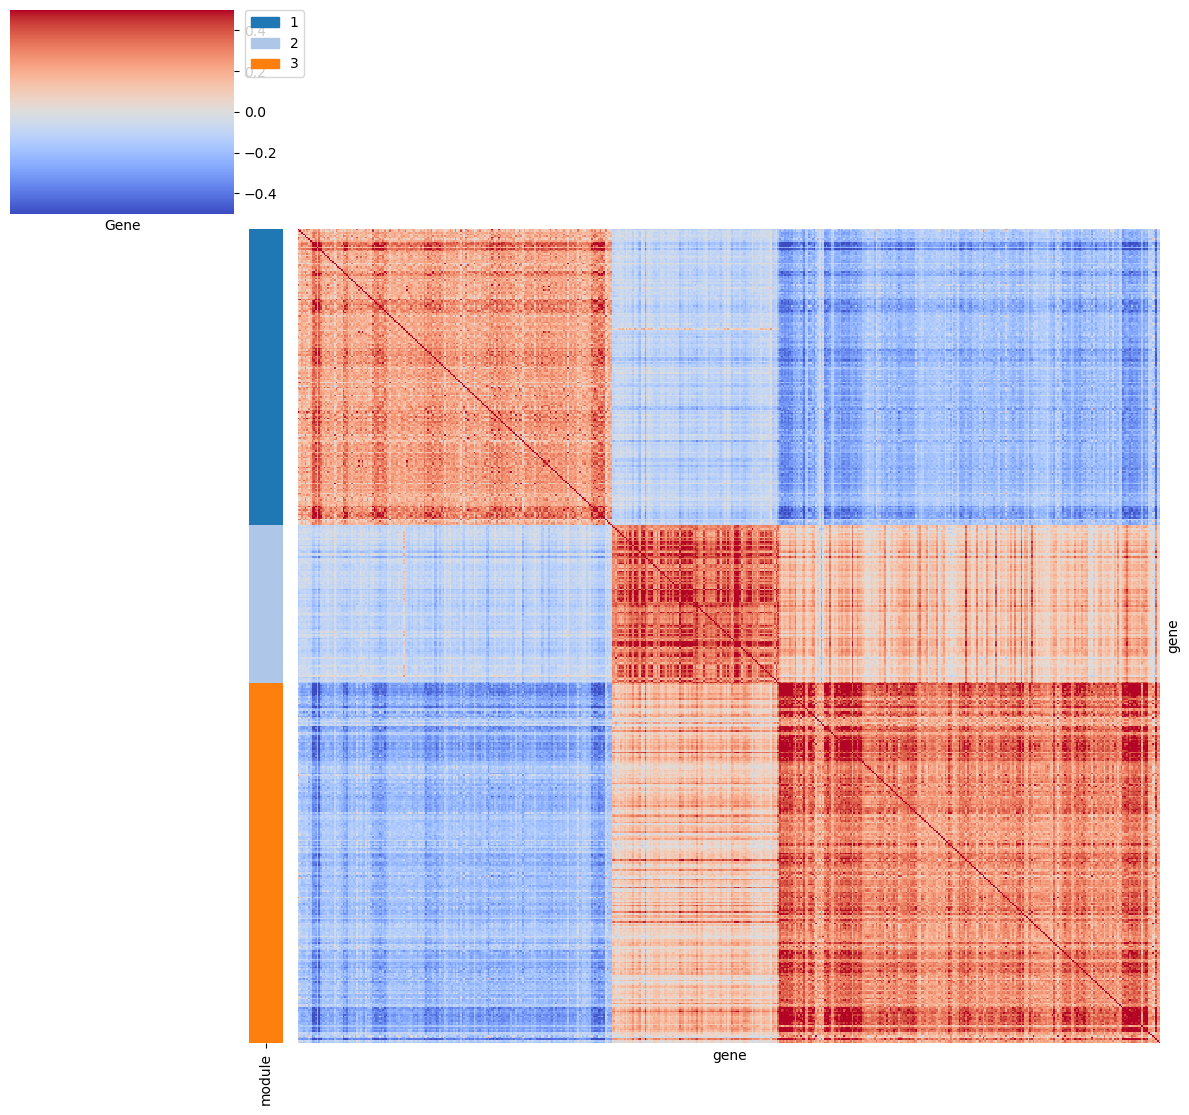

In [99]:
cond = "mmMYOD1"

# Top 500 genes
df = centrality_results[cond]['full']
top_genes = df.sort_values('degree', ascending=False).head(500).index
# corr = corr_matrices[cond].loc[top_genes, top_genes]
corr = corr_matrices_notabs[cond].loc[top_genes, top_genes]

# Compute distance matrix
dist = 1 - corr
dist_values = squareform(dist.values, checks=False)

# Perform hierarchical clustering
Z = linkage(dist_values, method='average')

t_min = 0
t_max = Z[:, 2].max()
print(f"t can range from {t_min:.4f} to {t_max:.4f}")

# Cut the dendrogram to form clusters (modules)
t = 0.83  # Adjust this threshold as needed
clusters = fcluster(Z, t, criterion='distance')

# Create a DataFrame to map genes to their respective modules
modules_df = pd.DataFrame({'gene': corr.index, 'module': clusters})
modules_df = modules_df.set_index('gene')

# Order genes by module
modules_df_sorted = modules_df.sort_values('module')
order = modules_df_sorted.index
corr_ordered = corr.loc[order, order]

# Assign colors to modules
unique_modules = sorted(modules_df['module'].unique())
palette = sns.color_palette("tab20", n_colors=len(unique_modules))
module_to_color = dict(zip(unique_modules, palette))
row_colors_ordered = modules_df_sorted['module'].map(module_to_color)

# Plot the heatmap
g = sns.clustermap(
    corr_ordered,
    cmap='coolwarm',
    center=0,
    vmin=-0.5, vmax=0.5,
    row_cluster=False,
    col_cluster=False,
    figsize=(12, 12),
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors_ordered,
)

plt.ylabel("")
plt.xlabel("Gene")

g.cax.set_position([0.05, 0.85, 0.015, 0.2]) # [x0, y0, width, height]

# --- Add a legend for the module colors ---
patches = [mpatches.Patch(color=color, label=f'{mod}') 
           for mod, color in module_to_color.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

In [102]:
gene_list = modules_df_sorted[modules_df_sorted['module'] == 3].index.unique().tolist()
print(len(gene_list))

database = "GO_Biological_Process_2025"

enr = gget.enrichr(gene_list, database, save=False)

enr.head(10)

19:12:08 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


221


,rank,path_name,p_val,z_score,combined_score,overlapping_genes,adj_p_val,database
0,1,Supramolecular Fiber Organization (GO:0097435),1.310117e-09,6.069964,124.149875,"[CAP1, HSP90AB1, TPM4, TPM3, SH3KBP1, TPM2, AC...",0.000002,GO_Biological_Process_2025
1,2,Regulation of Cell Migration (GO:0030334),1.912168e-08,4.674181,83.071609,"[ITGB1, HSPA8, IFITM1, CD151, SERPINE2, IGFBP5...",0.000011,GO_Biological_Process_2025
2,3,Regulation of Apoptotic Process (GO:0042981),1.942061e-08,3.926921,69.730071,"[ITGB1, PRKDC, IFI6, HSPB1, HMGB1, THBS1, FSTL...",0.000011,GO_Biological_Process_2025
3,4,ATP Metabolic Process (GO:0046034),3.964303e-07,13.719353,202.233771,"[HSPA8, LDHA, NT5E, TPI1, PKM, PARP1, ENO1, GA...",0.000168,GO_Biological_Process_2025
4,5,Response to Unfolded Protein (GO:0006986),4.952124e-07,17.453145,253.389627,"[HSPA8, TRAM1, HSP90AA1, HSP90AB1, SERPINH1, H...",0.000168,GO_Biological_Process_2025
5,6,Regulation of Plasminogen Activation (GO:0010755),6.227717e-07,41.599327,594.416346,"[SERPINE2, SERPINE1, ENO1, THBS1, S100A10]",0.000176,GO_Biological_Process_2025
6,7,Positive Regulation of Cell Migration (GO:0030...,1.518245e-06,4.628435,62.011571,"[ITGB1, HSPA8, SPARC, CD151, CAV1, FN1, FBLN1,...",0.000339,GO_Biological_Process_2025
7,8,Regulation of Substrate Adhesion-Dependent Cel...,1.604083e-06,14.344548,191.398709,"[MDK, FBLN1, ACTN4, CALR, P4HB, GBP1, S100A10]",0.000339,GO_Biological_Process_2025
8,9,Regulation of Programmed Cell Death (GO:0043067),1.862963e-06,6.148247,81.115927,"[PRDX2, HSP90AA1, LGALS1, ACTN1, ANP32E, NME2,...",0.000350,GO_Biological_Process_2025
9,10,Response to Type II Interferon (GO:0034341),4.296668e-06,12.174396,150.447179,"[IFITM3, BST2, IFITM1, NUB1, IFITM2, GAPDH, GBP1]",0.000727,GO_Biological_Process_2025


# Hotspot-ish

In [14]:
bdata = adata[:, adata.var['gene_type'] == 'protein_coding'].copy()

bdata

AnnData object with n_obs × n_vars = 15950 × 15786
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [15]:
np.random.seed(42)

# Sample 500 cells per condition
sampled_indices = (
    bdata.obs
    .groupby('pooled_condition', group_keys=False)
    .apply(lambda x: x.sample(n=500, replace=False, random_state=42))
    .index
)

# Subset the AnnData object
bdata = bdata[sampled_indices].copy()

print(f"Total sampled cells: {bdata.n_obs}")
print(bdata.obs['pooled_condition'].value_counts())

/tmp/ipykernel_3349450/1383252980.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('pooled_condition', group_keys=False)
/tmp/ipykernel_3349450/1383252980.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=500, replace=False, random_state=42))


Total sampled cells: 2000
pooled_condition
Control            500
mmMYOD1            500
siPRRX1            500
siPRRX1/mmMYOD1    500
Name: count, dtype: int64


In [16]:
bdata.X = bdata.layers['raw_counts'].copy()

sc.pp.highly_variable_genes(
    bdata,
    flavor='seurat_v3',
    n_top_genes=5000,
    batch_key='dataset',
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
bdata

AnnData object with n_obs × n_vars = 2000 × 5000
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'mea

In [17]:
bdata.X = bdata.layers['log_norm'].copy()
X_dense = bdata.X.toarray() if isinstance(bdata.X, csr_matrix) else bdata.X
print(X_dense.shape)

(2000, 5000)


In [33]:
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from statsmodels.sandbox.stats.multicomp import multipletests

In [18]:
K_NEIGHBORS = 30
N_PERMUTATIONS = 100 # Hotspot typically uses hundreds or thousands of permutations for statistical rigor
FDR_CUTOFF = 0.05

print(f"1. Computing KNN graph (k={K_NEIGHBORS}) from latent space...")
W = kneighbors_graph(bdata.obsm['X_pca_harmony'], K_NEIGHBORS, 
                     mode='connectivity', include_self=False, metric='euclidean')
W = W.tocsr()
print(f"   Graph shape: {W.shape}")
W_sum = W.sum()


def morans_i_calculation(W, expression_vector):
    """Calculates Moran's I for a single expression vector."""
    n = len(expression_vector)
    x = expression_vector - np.mean(expression_vector)
    
    # Numerator: x^T * W * x (Sum of products of deviations between neighbors)
    numerator = x.T @ W @ x
    
    # Denominator: Sum of squared deviations
    denominator = np.sum(x**2)
    
    if W_sum == 0 or denominator == 0:
        return 0.0 
    
    return (n / W_sum) * (numerator / denominator)

1. Computing KNN graph (k=30) from latent space...
   Graph shape: (2000, 2000)


In [19]:
# --- Step 2: Find Informative Genes via Permutations (Z-scores, P-values, FDR) ---
print(f"\n2. Calculating Moran's I and performing {N_PERMUTATIONS} permutations for each gene...")

gene_metrics = []

for i in range(X_dense.shape[1]):
    gene_name = bdata.var_names[i]
    expression = X_dense[:, i]

    # Calculate OBSERVED Moran's I (I_obs)
    I_obs = morans_i_calculation(W, expression)
    
    # Run Permutation Test
    I_permutations = []
    for _ in range(N_PERMUTATIONS):
        # Permutation: shuffle the cell indices and calculate Moran's I
        permuted_expression = np.random.permutation(expression)
        I_perm = morans_i_calculation(W, permuted_expression)
        I_permutations.append(I_perm)
    
    I_permutations = np.array(I_permutations)
    
    # Calculate Z-score (Empirical Z-score)
    mean_perm = np.mean(I_permutations)
    std_perm = np.std(I_permutations)
    
    # Avoid division by zero if all permutations resulted in the exact same score
    Z_score = (I_obs - mean_perm) / std_perm if std_perm != 0 else 0.0
    
    # Calculate Empirical P-value
    # P-value = (Number of permuted scores >= I_obs) / N_PERMUTATIONS
    p_value = (np.sum(I_permutations >= I_obs) + 1) / (N_PERMUTATIONS + 1) # Add 1 for stability
    
    gene_metrics.append({
        'gene': gene_name,
        'morans_i': I_obs,
        'Z_score': Z_score,
        'p_value': p_value
    })

df_scores = pd.DataFrame(gene_metrics).sort_values('morans_i', ascending=False)


2. Calculating Moran's I and performing 100 permutations for each gene...


In [30]:
# Apply Benjamini-Hochberg (BH) FDR Correction
# multipletests returns (reject, pvals_corrected, _, _)
reject, fdr_pvalues, _, _ = multipletests(df_scores['p_value'].values, method='fdr_bh')
df_scores['fdr'] = fdr_pvalues

# Filter for Informative Genes
informative_genes_df = df_scores[df_scores['fdr'] < FDR_CUTOFF].reset_index(drop=True)
print(f"   Identified {len(informative_genes_df)} informative genes (FDR < {FDR_CUTOFF}).")

if not informative_genes_df.empty:
    # --- Step 3: Group Informative Genes into Modules (Local Correlation & Clustering) ---
    print("\n3. Computing graph-smoothed local correlation and clustering...")
    
    # 3a. Get expression matrix for only the informative genes
    gene_index_object = pd.Index(bdata.var_names)
    gene_indices = gene_index_object.get_indexer(informative_genes_df['gene'])
    X_informative = X_dense[:, gene_indices]
    # gene_indices = [bdata.var_names.index(g) for g in informative_genes_df['gene']]
    # X_informative = X_dense[:, gene_indices]
    
    # 3b. Normalize expression (Z-score scaling per gene)
    X_normalized = (X_informative - X_informative.mean(axis=0)) / X_informative.std(axis=0)
    
    # 3c. Graph Smoothing: Average gene expression based on the cell's neighbors.
    # Row-normalize W for smoothing: W_norm is the proportion of influence from neighbors
    W_norm = W / W.sum(axis=1)[:, np.newaxis] 
    X_smoothed = W_norm.dot(X_normalized)
    
    # 3d. Local Correlation: Compute standard Pearson correlation on the smoothed matrix
    local_correlation_matrix = pd.DataFrame(np.corrcoef(X_smoothed.T), 
                                            index=informative_genes_df['gene'], 
                                            columns=informative_genes_df['gene'])
    
    # 3e. Hierarchical Clustering
    # Convert correlation (similarity) to distance (using absolute correlation)
    distance_matrix = 1 - local_correlation_matrix.abs().values
    
    # Use only the upper triangle of the distance matrix for linkage
    dist_vector = distance_matrix[np.triu_indices(distance_matrix.shape[0], k=1)]
    
    # Perform clustering
    linked = linkage(dist_vector, method='ward')
    
    # Cut the dendrogram to define modules (using a distance threshold, e.g., 0.8)
    MODULE_CUTOFF = 0.8
    module_assignments = fcluster(linked, t=MODULE_CUTOFF, criterion='distance')
    
    # Map results back to genes
    module_results = pd.DataFrame({
        'gene': informative_genes_df['gene'].tolist(),
        'module_id': module_assignments
    }).sort_values('module_id')
    
    module_results['genes_per_module'] = module_results['module_id'].map(module_results['module_id'].value_counts())
    
    # --- FINAL OUTPUT ---
    print("\n--- Informative Genes (Top 5 by Z-Score) ---")
    print(df_scores.sort_values('Z_score', ascending=False).head(5).to_string(index=False, float_format="{:.4f}".format))
    
    print("\n--- Final Gene Module Assignments (First 10) ---")
    print(module_results.head(10).to_string(index=False))
    
    print(f"\nTotal Modules Found: {module_results['module_id'].nunique()}")
    # print("Module sizes:")
    # print(module_results['module_id'].value_counts().sort_index().to_string())
else:
    print("\nNo genes passed the FDR cutoff. Cannot form modules.")

module_results.head()

   Identified 4004 informative genes (FDR < 0.05).

3. Computing graph-smoothed local correlation and clustering...

--- Informative Genes (Top 5 by Z-Score) ---
   gene  morans_i  Z_score  p_value    fdr
  MYOD1    0.7129 161.8844   0.0099 0.0134
  RPLP1    0.7053 153.6401   0.0099 0.0134
HSP90B1    0.6867 148.0589   0.0099 0.0134
  GAPDH    0.6014 143.6532   0.0099 0.0134
   ACTB    0.7043 143.3469   0.0099 0.0134

--- Final Gene Module Assignments (First 10) ---
  gene  module_id  genes_per_module
ZNF878          1                 3
 CECR2          1                 3
 MYO5B          1                 3
  GBA2          2                 3
  SORD          2                 3
SH3TC1          2                 3
 NPHP1          3                 2
 HTRA4          3                 2
  BEX1          4                 2
  DLX2          4                 2

Total Modules Found: 467


,gene,module_id,genes_per_module
3854,ZNF878,1,3
3845,CECR2,1,3
3348,MYO5B,1,3
3859,GBA2,2,3
3472,SORD,2,3


In [29]:
module_results.sort_values('genes_per_module', ascending=False).head()

,gene,module_id,genes_per_module
1637,SPC24,181,81
99,MKI67,181,81
788,CBX5,181,81
554,NDC80,181,81
459,KIF2C,181,81



3. Computing graph-smoothed local correlation and clustering...

4. Generating Symmetric Gene-Gene Correlation Clustermap for Top 500 Genes...


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


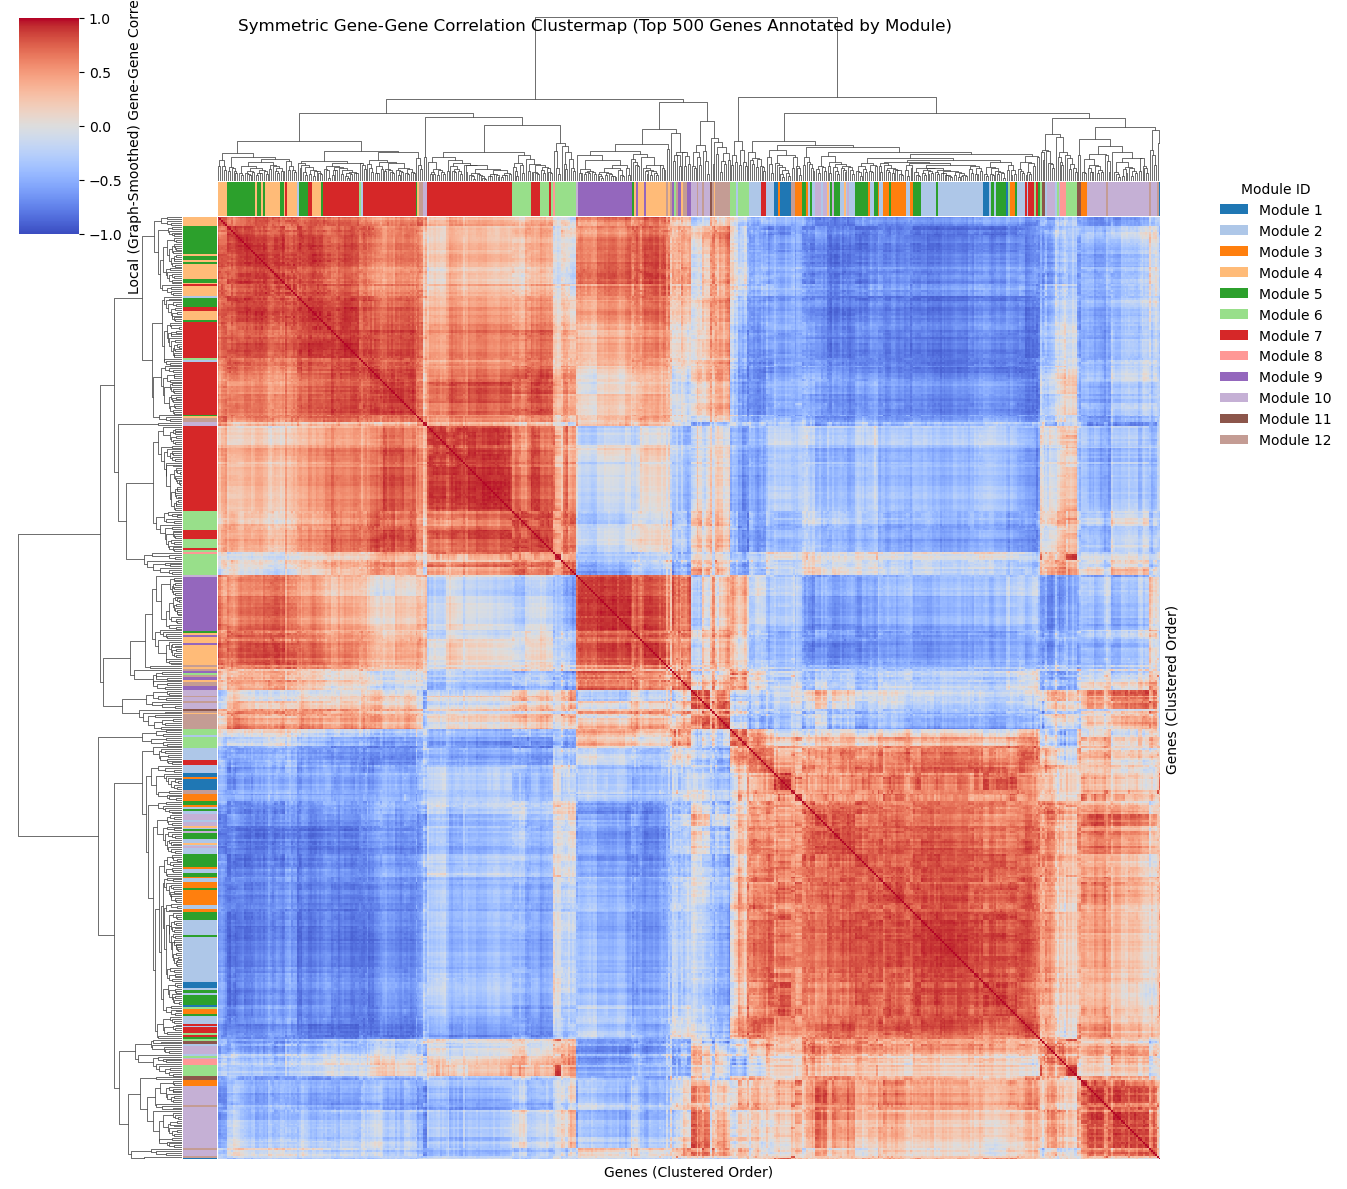

In [35]:
N_HEATMAP_GENES = 500
N_MODULES = 12

if not informative_genes_df.empty:
    # --- Step 3: Group Informative Genes into Modules (Local Correlation & Clustering) ---
    print("\n3. Computing graph-smoothed local correlation and clustering...")
    
    # 3a. Get expression matrix for only the informative genes
    # FIX: Use pd.Index().get_indexer() to safely map gene names back to column indices,
    # avoiding the AttributeError if adata.var_names is a pandas Index object.
    gene_index_object = pd.Index(bdata.var_names)
    gene_indices = gene_index_object.get_indexer(informative_genes_df['gene'])
    X_informative = X_dense[:, gene_indices]
    
    # 3b. Normalize expression (Z-score scaling per gene)
    X_normalized = (X_informative - X_informative.mean(axis=0)) / X_informative.std(axis=0)
    
    # 3c. Graph Smoothing: Average gene expression based on the cell's neighbors.
    # Row-normalize W for smoothing: W_norm is the proportion of influence from neighbors
    # Note: np.sum(axis=1) on a sparse matrix returns a matrix, need to convert to array.
    W_sum_array = W.sum(axis=1).A.flatten()
    # Mask to prevent division by zero in case of isolated cells (sum=0)
    W_norm = W.copy() 
    W_norm.data /= W_sum_array[W_norm.indices]
    
    X_smoothed = W_norm.dot(X_normalized)
    
    # 3d. Local Correlation: Compute standard Pearson correlation on the smoothed matrix
    local_correlation_matrix = pd.DataFrame(np.corrcoef(X_smoothed.T), 
                                            index=informative_genes_df['gene'], 
                                            columns=informative_genes_df['gene'])
    
    # 3e. Hierarchical Clustering
    # Convert correlation (similarity) to distance (using absolute correlation)
    distance_matrix = 1 - local_correlation_matrix.abs().values
    
    # Use only the upper triangle of the distance matrix for linkage
    dist_vector = distance_matrix[np.triu_indices(distance_matrix.shape[0], k=1)]
    
    # Perform clustering
    linked = linkage(dist_vector, method='ward')
    
    # Cut the dendrogram to define exactly 12 modules
    module_assignments = fcluster(linked, t=N_MODULES, criterion='maxclust')
    
    # Map results back to genes
    module_results = pd.DataFrame({
        'gene': informative_genes_df['gene'].tolist(),
        'module_id': module_assignments
    }).sort_values('module_id')
    
    # Calculate gene count per module using map and assign it to the new column
    module_results['genes_per_module'] = module_results['module_id'].map(module_results['module_id'].value_counts())
    
    print(f"\n4. Generating Symmetric Gene-Gene Correlation Clustermap for Top {N_HEATMAP_GENES} Genes...")

    if len(informative_genes_df) >= N_HEATMAP_GENES:
        # 4a. Filter module assignments to top N genes
        top_genes_df = df_scores.sort_values('Z_score', ascending=False).head(N_HEATMAP_GENES).copy()
        
        # Merge module assignments onto the top genes
        top_genes_df = top_genes_df.merge(module_results[['gene', 'module_id']], on='gene', how='left')
        
        heatmap_gene_names = top_genes_df['gene'].tolist()

        # 4b. Filter the Local Correlation Matrix (Gene x Gene)
        corr_heatmap = local_correlation_matrix.loc[heatmap_gene_names, heatmap_gene_names]
        
        # 4c. Prepare module color annotation (sidebar)
        # Create a consistent color map for the N_MODULES total
        unique_modules = module_results['module_id'].unique()
        module_colors = sns.color_palette("tab20", n_colors=max(unique_modules)) 
        module_map = dict(zip(sorted(unique_modules), module_colors))
        
        # Get the color vector for the genes in the current heatmap order (Z-score order)
        # This list will be internally reordered by clustermap
        row_colors_list = top_genes_df.set_index('gene').loc[heatmap_gene_names, 'module_id'].map(module_map).tolist()
        
        # 4d. Plotting the integrated clustermap
        # Clustermap handles linkage, dendrogram, and heatmap integration.
        g = sns.clustermap(corr_heatmap,
                           cmap="coolwarm", 
                           center=0,
                           vmin=-1, vmax=1,
                           row_cluster=True,  # Enable clustering and dendrogram
                           col_cluster=True,  # Enable clustering and dendrogram
                           dendrogram_ratio=(0.15, 0.15), # Adjust space for dendrograms
                           linewidths=0,
                           figsize=(12, 12),
                           row_colors=row_colors_list, # Annotate rows with module colors
                           col_colors=row_colors_list, # Annotate columns with module colors
                           xticklabels=False,
                           yticklabels=False,
                           cbar_kws={'label': 'Local (Graph-Smoothed) Gene-Gene Correlation'}
                          )

        # Move the title to the figure to avoid overlap with the dendrogram
        g.fig.suptitle(f'Symmetric Gene-Gene Correlation Clustermap (Top {N_HEATMAP_GENES} Genes Annotated by Module)')
        
        # Clean up axis labels
        g.ax_heatmap.set_xlabel('Genes (Clustered Order)')
        g.ax_heatmap.set_ylabel('Genes (Clustered Order)')
        
        # Create a legend to map colors to module IDs
        legend_elements = [plt.Rectangle((0, 0), 1, 1, fc=module_map[mid], label=f'Module {mid}')
                           for mid in sorted(unique_modules) if mid in top_genes_df['module_id'].unique()]
        
        # Add legend to the figure
        g.ax_heatmap.legend(handles=legend_elements, title="Module ID", 
                            bbox_to_anchor=(1.05, 1.05), loc='upper left', frameon=False)
        
        plt.show()
    else:
        print(f"   WARNING: Only {len(informative_genes_df)} informative genes found. Cannot plot {N_HEATMAP_GENES}.")
#     print(f"\n4. Generating Symmetric Gene-Gene Correlation Heatmap for Top {N_HEATMAP_GENES} Genes...")

#     if len(informative_genes_df) >= N_HEATMAP_GENES:
#         # 4a. Filter module assignments to top N genes
#         # Get top N genes by Z-score
#         top_genes_df = df_scores.sort_values('Z_score', ascending=False).head(N_HEATMAP_GENES).copy()
        
#         # Merge module assignments onto the top genes
#         top_genes_df = top_genes_df.merge(module_results[['gene', 'module_id']], on='gene', how='left')
#         top_genes_df = top_genes_df.sort_values('module_id', ascending=True)
        
#         heatmap_gene_names = top_genes_df['gene'].tolist()

#         # 4b. Filter and sort the Local Correlation Matrix (Gene x Gene)
#         # We subset the full local_correlation_matrix (all informative genes)
#         # to include only the top N_HEATMAP_GENES, sorted by module ID.
#         corr_heatmap = local_correlation_matrix.loc[heatmap_gene_names, heatmap_gene_names]
        
#         # 4c. Plotting the symmetric correlation heatmap
#         plt.figure(figsize=(10, 10))
        
#         sns.heatmap(corr_heatmap,
#                     cmap="coolwarm", # Use coolwarm for correlation
#                     center=0,
#                     vmin=-1, vmax=1, # Ensure limits cover the full correlation range
#                     xticklabels=False, # Hide labels for dense plot
#                     yticklabels=False,
#                     cbar_kws={'label': 'Local (Graph-Smoothed) Gene-Gene Correlation'},
#                     rasterized=True
#                    )
    
#         plt.title(f'Gene-Gene Correlation Heatmap (Top {N_HEATMAP_GENES} Genes, {N_MODULES} Modules)')
#         plt.xlabel(f'Genes')
#         plt.ylabel(f'Genes')
#         plt.tight_layout()
#         plt.show()
#     else:
#         print(f"   WARNING: Only {len(informative_genes_df)} informative genes found. Cannot plot {N_HEATMAP_GENES}.")

#

In [50]:
%%time
conditions = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

corr_matrices = {}
centrality_results = {}
threshold = 0.2

# bdata = adata[:, adata.var['highly_variable']].copy()
bdata = adata[:, adata.var['gene_type'] == 'protein_coding'].copy()

for cond in conditions:
    print(f"\nProcessing condition: {cond}")
    
    tmp = bdata[bdata.obs['pooled_condition'] == cond].copy()
    
    X = tmp.layers['log_norm']
    
    if sparse.issparse(X):
        X = X.toarray()
    else:
        X = np.array(X)
    print(f"Expression shape: {X.shape}")
    
    # Center and scale
    X_centered = X - X.mean(axis=0, keepdims=True)
    stds = X_centered.std(axis=0, ddof=1)
    stds[stds == 0] = np.nan  # avoid divide by 0
    
    corr_matrix = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)
    corr_matrix = corr_matrix / np.outer(stds, stds)
    np.fill_diagonal(corr_matrix, 1.0)
    
    gene_names = bdata.var_names
    corr_df = pd.DataFrame(corr_matrix, index=gene_names, columns=gene_names)
    
    corr_matrices[cond] = corr_df
    
    # absolute corr
    corr_abs = corr_df.abs()
    corr_thresh = corr_abs.where(corr_abs >= threshold, other=0)
    
    # Build graph
    G = nx.from_pandas_adjacency(corr_thresh)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc).copy()
        print(f"Largest component: {len(G_sub)} genes (of {len(G)})")
    else:
        G_sub = G
    
    # Centralities
    degree_centrality = dict(G_sub.degree(weight='weight'))
    eigenvector_centrality = nx.eigenvector_centrality_numpy(G_sub, weight='weight')
    
    centrality_df = pd.DataFrame({
        'degree': pd.Series(degree_centrality),
        'eigenvector': pd.Series(eigenvector_centrality)
    })
    
    # Top 50
    top_degree = centrality_df.sort_values('degree', ascending=False).head(50)
    top_eigenvector = centrality_df.sort_values('eigenvector', ascending=False).head(50)
    
    # Store results
    centrality_results[cond] = {
        'full': centrality_df,
        'top_degree': top_degree,
        'top_eigenvector': top_eigenvector
    }
    
    print(f"Top 10 degree centrality genes for {cond}:")
    display(top_degree.head(10))
    print(f"Top 10 eigenvector centrality genes for {cond}:")
    display(top_eigenvector.head(10))
    
    break


Processing condition: Control
Expression shape: (6960, 15786)
Largest component: 2050 genes (of 15786)
Top 10 degree centrality genes for Control:


,degree,eigenvector
TOP2A,349.199357,0.090566
STMN1,349.184782,0.088221
PRC1,343.361206,0.088853
CENPF,341.723467,0.089289
HMGB2,338.826989,0.088550
TPX2,337.665650,0.087864
NUSAP1,336.381313,0.089087
MKI67,332.771904,0.086350
TUBA1B,325.849585,0.082670
PTTG1,321.384475,0.086296


Top 10 eigenvector centrality genes for Control:


,degree,eigenvector
TOP2A,349.199357,0.090566
CENPF,341.723467,0.089289
NUSAP1,336.381313,0.089087
PRC1,343.361206,0.088853
HMGB2,338.826989,0.088550
STMN1,349.184782,0.088221
TPX2,337.665650,0.087864
MKI67,332.771904,0.086350
PTTG1,321.384475,0.086296
ASPM,313.643035,0.084511


CPU times: user 33.2 s, sys: 10.1 s, total: 43.3 s
Wall time: 43.7 s


In [9]:
condition = 'mmMYOD1'

bdata = adata[adata.obs['pooled_condition'] == condition].copy()
bdata = bdata[:, bdata.var['highly_variable']]
bdata

View of AnnData object with n_obs × n_vars = 2109 × 2000
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_ran

In [ ]:
X = bdata.layers['log_norm'].copy()

# convert sparse to dense
if sparse.issparse(X):
    X = X.toarray()             
else:
    X = np.array(X)

print(X.shape)

# Center and scale each gene (z-score across cells)
X_centered = X - X.mean(axis=0, keepdims=True)

stds = X_centered.std(axis=0, ddof=1)
stds[stds == 0] = np.nan # avoid divide by 0

# Compute correlation (genes × genes)
corr_matrix = (X_centered.T @ X_centered) / (len(X_centered) - 1)
corr_matrix = corr_matrix / np.outer(stds, stds)
np.fill_diagonal(corr_matrix, 1.0)

# Convert to DataFrame
gene_names = bdata.var_names
corr_df = pd.DataFrame(corr_matrix, index=gene_names, columns=gene_names)
print(corr_df.shape)

corr_df.head()

(2109, 2000)
(2000, 2000)


gene_name,A2M,AARD,ABCA9,ABCC6P1,ABCG5,ABI3BP,ABL2,ACAN,ACKR4,ACSBG1,...,ZFPM2-AS1,ZMAT4,ZMYND15,ZNF366,ZNF554,ZNF608,ZNF80,ZNF804A,ZNF98,ZSCAN10
gene_name,,,,,,,,,,,,,,,,,,,,,
A2M,1.000000,0.035032,-0.016710,-0.006143,-0.002114,-0.027479,-0.031159,0.006856,-0.010244,0.007529,...,-0.011094,-0.003914,-0.006160,-0.008471,0.027739,-0.026422,-0.005644,-0.013336,-0.003496,-0.002114
AARD,0.035032,1.000000,-0.012007,0.002426,-0.003766,-0.008001,-0.049564,0.019815,-0.020784,-0.020640,...,-0.007829,-0.006974,-0.010974,-0.015091,-0.017384,-0.017632,-0.010054,-0.025013,-0.006227,-0.003766
ABCA9,-0.016710,-0.012007,1.000000,-0.010895,-0.003750,0.076996,0.087257,-0.007526,-0.037895,0.021823,...,0.032241,0.064512,-0.010925,0.095169,0.124679,0.159356,-0.010009,0.015629,0.054573,-0.003749
ABCC6P1,-0.006143,0.002426,-0.010895,1.000000,-0.001378,-0.005010,0.048944,-0.005393,-0.038270,-0.007554,...,-0.020309,-0.002552,-0.004016,-0.005523,0.062089,0.017163,-0.003680,0.040743,-0.002279,-0.001378
ABCG5,-0.002114,-0.003766,-0.003750,-0.001378,1.000000,-0.011532,-0.011638,-0.001856,-0.016032,-0.002600,...,-0.008661,-0.000878,-0.001382,-0.001901,-0.005071,-0.005929,-0.001266,-0.011593,-0.000784,-0.000474


In [33]:
### Absolute values
corr_abs = corr_df.abs()

threshold = 0.2
corr_thresh = corr_abs.where(corr_abs >= threshold, other=0)

# Build graph
G = nx.from_pandas_adjacency(corr_thresh)

if not nx.is_connected(G):
    # Extract the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    print(f"Largest component: {len(G_sub)} genes (of {len(G)})")
else:
    G_sub = G


# Compute centralities
degree_centrality = dict(G_sub.degree(weight='weight'))
eigenvector_centrality = nx.eigenvector_centrality_numpy(G_sub, weight='weight')

# Combine into DataFrame
centrality_df = pd.DataFrame({
    'degree': pd.Series(degree_centrality),
    'eigenvector': pd.Series(eigenvector_centrality)
})

# Top 50
top_degree = centrality_df.sort_values('degree', ascending=False).head(50)
top_eigenvector = centrality_df.sort_values('eigenvector', ascending=False).head(50)

display(top_degree.head(10))
display(top_eigenvector.head(10))

Largest component: 1699 genes (of 2000)


,degree,eigenvector
PTMA,187.487778,0.107188
GAPDH,174.276990,0.103899
PPP1R15A,172.331937,0.102523
HDAC9,157.906254,0.096479
ACTB,156.196068,0.093340
ENSG00000274213,155.425407,0.095891
NME2,149.884062,0.093262
LURAP1L-AS1,149.184562,0.086400
TPM3,148.605596,0.089934
IFITM2,148.113070,0.090274


,degree,eigenvector
PTMA,187.487778,0.107188
GAPDH,174.276990,0.103899
PPP1R15A,172.331937,0.102523
HDAC9,157.906254,0.096479
ENSG00000274213,155.425407,0.095891
ACTB,156.196068,0.093340
NME2,149.884062,0.093262
IFITM2,148.113070,0.090274
TPM3,148.605596,0.089934
RUNX1,139.797610,0.089325


In [34]:
### Only positive edges

corr_pos = corr_df.copy()
corr_pos[corr_pos < 0] = 0

threshold = 0.2
corr_thresh = corr_pos.where(corr_pos >= threshold, other=0)

# Build graph
G = nx.from_pandas_adjacency(corr_thresh)

if not nx.is_connected(G):
    # Extract the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    print(f"Largest component: {len(G_sub)} genes (of {len(G)})")
else:
    G_sub = G


# Compute centralities
degree_centrality = dict(G_sub.degree(weight='weight'))
eigenvector_centrality = nx.eigenvector_centrality_numpy(G_sub, weight='weight')

# Combine into DataFrame
centrality_df = pd.DataFrame({
    'degree': pd.Series(degree_centrality),
    'eigenvector': pd.Series(eigenvector_centrality)
})

# Top 50
top_degree = centrality_df.sort_values('degree', ascending=False).head(50)
top_eigenvector = centrality_df.sort_values('eigenvector', ascending=False).head(50)

display(top_degree.head(10))
display(top_eigenvector.head(10))

Largest component: 1699 genes (of 2000)


,degree,eigenvector
ENSG00000287709,117.235290,0.080882
LURAP1L-AS1,112.866837,0.111593
LRRC7,110.727163,0.111323
PATL2,108.797680,0.104937
HDAC9,108.572774,0.111092
PPP1R15A,106.570293,0.105095
BACH2,103.989251,0.090205
TAFA3,102.501818,0.091437
SHROOM3,100.839785,0.103790
LRRC7-AS1,100.778058,0.094171


,degree,eigenvector
LURAP1L-AS1,112.866837,0.111593
LRRC7,110.727163,0.111323
HDAC9,108.572774,0.111092
LNCAROD,99.871777,0.106526
VXN,100.189806,0.106446
PPP1R15A,106.570293,0.105095
PATL2,108.797680,0.104937
PSG9,94.765417,0.104410
SHROOM3,100.839785,0.103790
PSG8-AS1,91.647834,0.102272
